# Análisis exploratorio de datos

In [1]:
#imports
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [3]:
DIRECTORIO_DATOS = 'dataset_4_letras'

#### Recopilación de metadatos

In [4]:
palabras = []
rutas_imagenes = []
dimensiones = set()

for palabra in os.listdir(DIRECTORIO_DATOS):
    ruta_palabra = os.path.join(DIRECTORIO_DATOS, palabra)
    if os.path.isdir(ruta_palabra):
        imagenes = os.listdir(ruta_palabra)
        for img_name in imagenes:
            ruta_img = os.path.join(ruta_palabra, img_name)
            palabras.append(palabra)
            rutas_imagenes.append(ruta_img)
            
            # Cogemos la dimensión de la primera imagen de cada carpeta para comprobar
            if len(dimensiones) < 5: 
                img_test = cv2.imread(ruta_img)
                dimensiones.add(img_test.shape)

df_dataset = pd.DataFrame({'Palabra': palabras, 'Ruta': rutas_imagenes})

print(f"\nTotal de imágenes generadas: {len(df_dataset)}")
print(f"Total de palabras únicas (clases base): {df_dataset['Palabra'].nunique()}")
print(f"Dimensiones de las imágenes (Alto, Ancho, Canales): {list(dimensiones)[0]}")


Total de imágenes generadas: 20000
Total de palabras únicas (clases base): 50
Dimensiones de las imágenes (Alto, Ancho, Canales): (128, 497, 3)


#### Balanceo de palabras

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_25628\880230234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_palabras.index, y=conteo_palabras.values, palette="viridis")


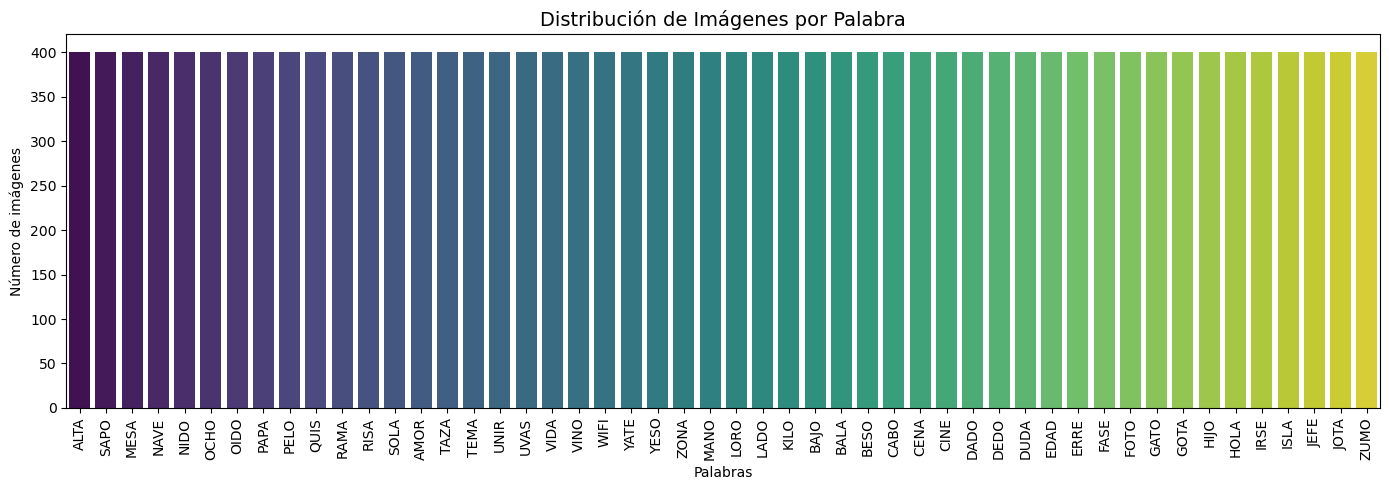

In [9]:
plt.figure(figsize=(14, 5))
conteo_palabras = df_dataset['Palabra'].value_counts()
sns.barplot(x=conteo_palabras.index, y=conteo_palabras.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Distribución de Imágenes por Palabra", fontsize=14)
plt.ylabel("Número de imágenes")
plt.xlabel("Palabras")
plt.tight_layout()
plt.show()

#### Frecuencia de letras individuales

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_25628\2030679489.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Letra', y='Frecuencia', data=df_letras, palette="magma")


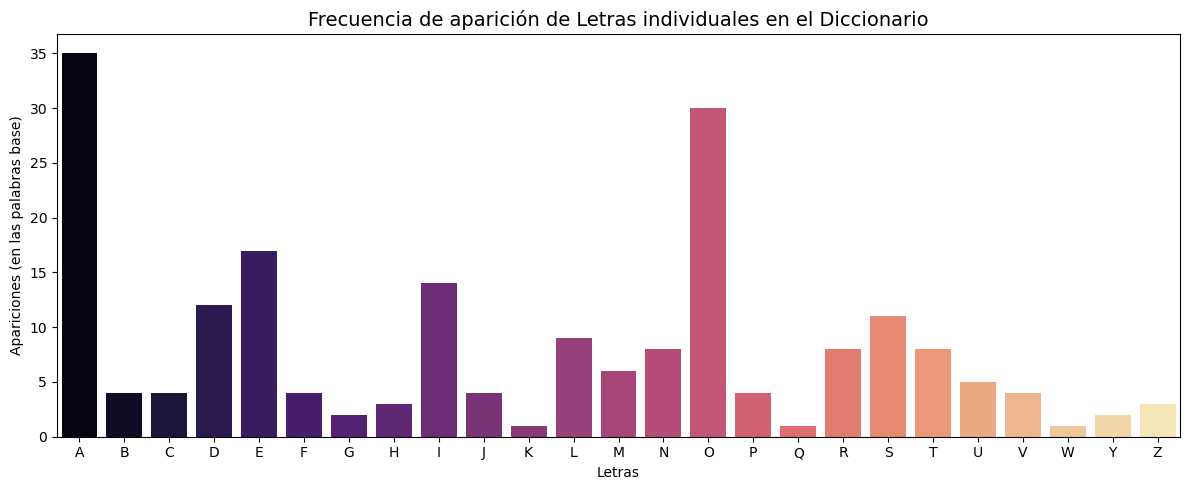

In [6]:
# Como el modelo predice letras, esta es la gráfica más importante para el EDA
todas_las_letras = "".join(df_dataset['Palabra'].unique())
conteo_letras = Counter(todas_las_letras)

# Convertir a DataFrame para Seaborn y ordenar alfabéticamente
df_letras = pd.DataFrame.from_dict(conteo_letras, orient='index', columns=['Frecuencia']).reset_index()
df_letras = df_letras.rename(columns={'index': 'Letra'}).sort_values('Letra')

plt.figure(figsize=(12, 5))
sns.barplot(x='Letra', y='Frecuencia', data=df_letras, palette="magma")
plt.title("Frecuencia de aparición de Letras individuales en el Diccionario", fontsize=14)
plt.ylabel("Apariciones (en las palabras base)")
plt.xlabel("Letras")
plt.tight_layout()
plt.show()

#### Visualización de muestra aleatoria

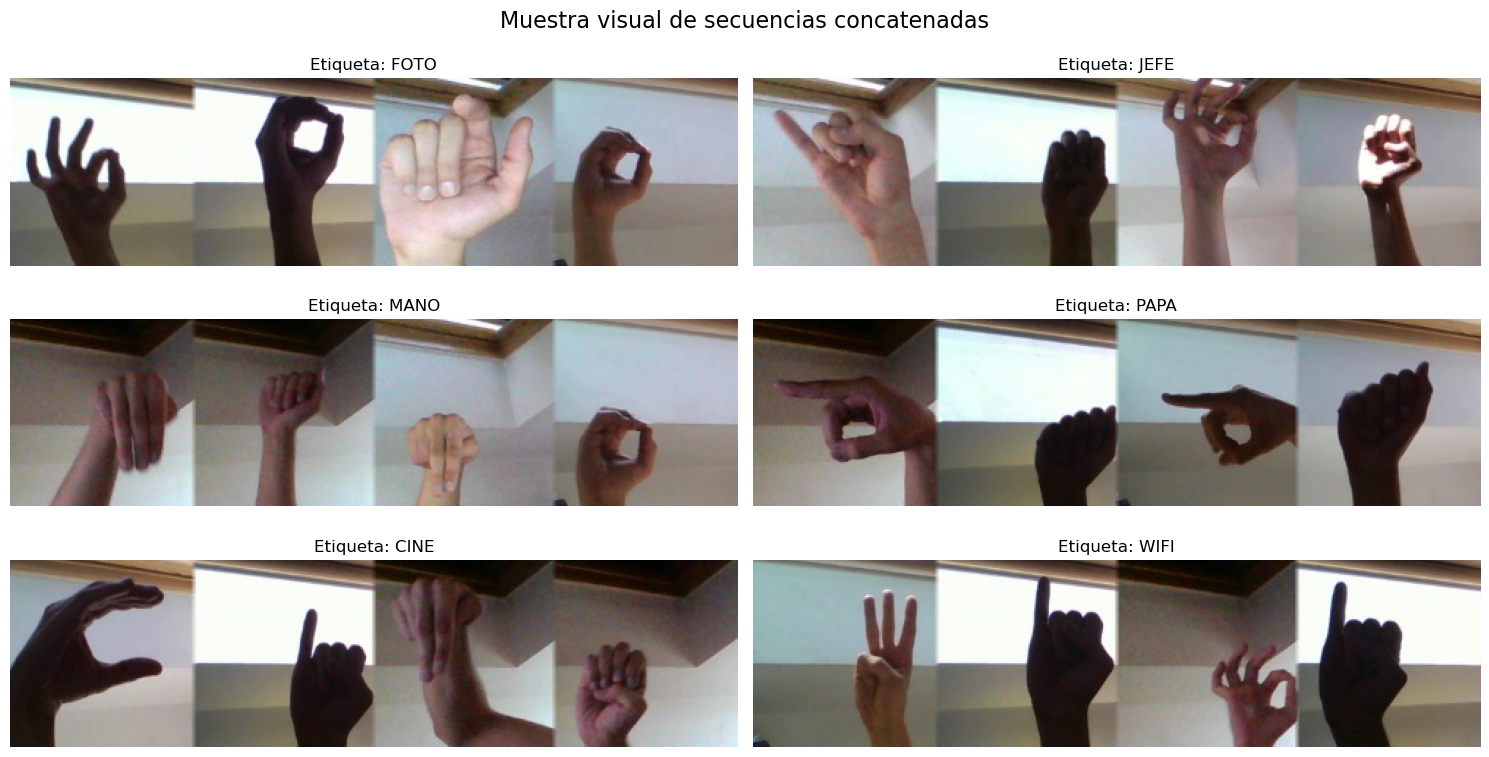

In [10]:
plt.figure(figsize=(15, 8))
muestras = df_dataset.sample(6)
for i, (index, row) in enumerate(muestras.iterrows()):
    plt.subplot(3, 2, i+1)
    img = cv2.imread(row['Ruta'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"Etiqueta: {row['Palabra']}")
    plt.axis('off')
plt.suptitle("Muestra visual de secuencias concatenadas", fontsize=16)
plt.tight_layout()
plt.show()

#### Distribución de pixeles

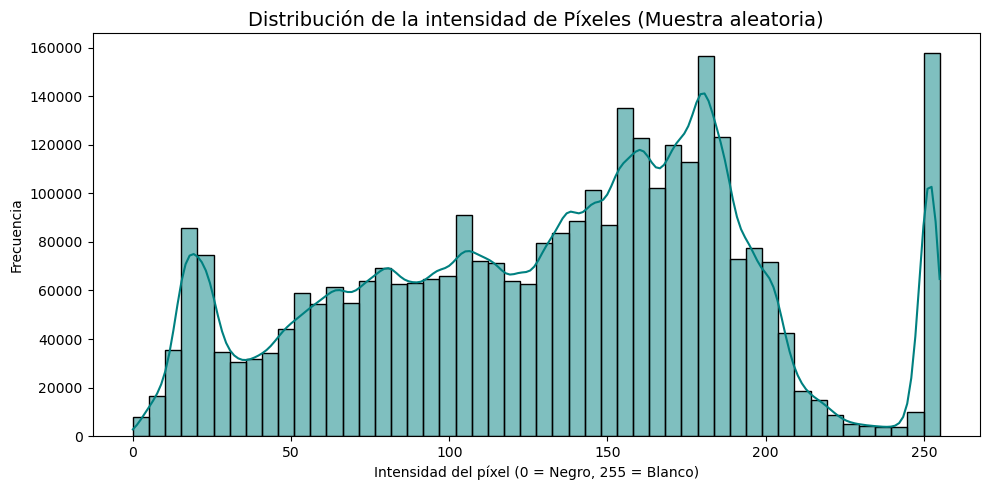

In [8]:
pixeles_muestra = []
for ruta in df_dataset['Ruta'].sample(50):
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    pixeles_muestra.extend(img.flatten())

plt.figure(figsize=(10, 5))
sns.histplot(pixeles_muestra, bins=50, color="teal", kde=True)
plt.title("Distribución de la intensidad de Píxeles (Muestra aleatoria)", fontsize=14)
plt.xlabel("Intensidad del píxel (0 = Negro, 255 = Blanco)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()